# FTL099 - Inteligência Artificial Aplicada  
Aluno: Nycksandro Lima dos Santos  
Matrícula: 22351228  

# Trabalho 02 - Classificadores Lineares  

Esse trabalho tem por objetivo classificar pacientes em duas classes, aquelas que têm câncer no ovário e aquelas que não têm câncer de ovário. Os dados são provenientes de exames de espectrometria de massa e contêm informações relativas a 100 intensidades de íons medidas para 100 diferentes valores específicos de massa-carga, para 216 pacientes diferentes. A base de dados é constituída por dois arquivos, descritos a seguir:

* ovarianInputs - uma matriz 216x100 que define 100 níveis de intensidade de íons medido para 100 diferentes valores específicos de massa-carga, para 216 pacientes diferentes.
* ovarianTargets - uma matriz 216x2 onde cada elemento indica um paciente com câncer de ovário com [1; 0] ou paciente normal com [0; 1]. Existem 121 pacientes com câncer e 95 pacientes normais.

Pede-se:

1) Que seja projetada um regressor logístico com uma camada, para classificação
desses dados.
2) Solicita-se que, para o treinamento e teste, os dados sejam divididos em 80%
para treinamento e 20% para teste. Não é necessário utilizada validação cruzada.
3) Solicita-se que sejam apresentados valores de acurácia, sensibilidade e
especificidade.


### Importando bibiliotecas

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn import preprocessing
import seaborn as sns
import matplotlib.pyplot as plt

### Lendo as Bases de Dados

In [ ]:
#Lendo as bases de dados
ovarianInputs_dt = pd.read_excel('/content/ovarianInputs.xlsx')
ovarianTargets_dt = pd.read_excel('/content/ovarianTargets.xls')

# Retirando linhas que possuem algum número vazio/nulo
ovarianInputs_dt.dropna()
ovarianTargets_dt.dropna()
print(f"Tamanho de ovarianInputs: {len(ovarianInputs_dt)}\nTamanho de ovarianTargets: {len(ovarianTargets_dt)}") #

Tamanho de ovarianInputs: 215
Tamanho de ovarianTargets: 215


In [ ]:
ovarianInputs_dt.head() # Vendo como os dados de ovarianInputs são

,0.462901,0.406736,0.306215,0.488105,0.175169,0.356551,0.439552,0.246779,1.373469,1.571959,...,0.519682,0.403089,0.189221,0.364127,0.261905,0.102007,1.669069,0.080098,0.144621,0.106405
0,0.370565,0.306431,0.239715,0.476358,0.175900,0.353762,0.476071,0.258894,1.338965,1.677094,...,0.614954,0.494679,0.181136,0.446832,0.164218,0.163589,2.232187,0.238168,0.186373,0.126373
1,0.461550,0.278980,0.206608,0.744342,0.152133,0.247645,0.304292,0.170356,1.047475,1.193578,...,1.485315,1.251828,0.377694,0.486562,0.088848,0.108145,2.142075,0.233619,0.175468,0.099903
2,0.375149,0.287317,0.241130,0.426810,0.205859,0.208770,0.283752,0.152572,1.213785,1.510149,...,0.819199,0.673698,0.214058,0.701985,0.230137,0.129792,1.951741,0.168771,0.136800,0.116469
3,0.113849,0.108411,0.086275,0.219954,0.050794,0.116163,0.188402,0.069726,0.705930,0.815952,...,2.187471,1.729508,0.440756,0.310229,0.139552,0.108191,3.917728,0.246519,0.079653,0.012750
4,0.233627,0.117294,0.059205,0.284276,0.047048,0.220356,0.282986,0.162463,0.917090,1.045686,...,3.240487,2.503369,0.665170,0.572055,0.143149,0.134398,3.067101,0.138255,0.055678,0.123548


In [ ]:
ovarianTargets_dt.head() # Vendo como os dados de ovarianTargets são

,1,0
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


Na base de dados ovarianTargets é possível utilizar apenas uma coluna como informação para o treinamento. Utilizar duas colunas é irrelevante, uma vez que, se eu sei que um objeto pertence a classe 1, logo sei que ele não pertence a classe 0 e o contrário também se aplica.

In [ ]:
ovarianTargets_dt.drop(0, axis=1, inplace=True) # Eliminando a coluna 0 (indice = 1)
ovarianTargets_dt.head()


,1
0,1
1,1
2,1
3,1
4,1


### Normalizando a base de dados

In [ ]:
normalizador = preprocessing.MinMaxScaler()

x = normalizador.fit_transform(ovarianInputs_dt) # Normalizando o ovarianInputs
y = np.where(ovarianTargets_dt==0, -1, 1).ravel() # Como o regressor logistico necessita classificar se faz parte da classe 1 ou -1, vou precisar adaptar essa base de dados, alterando de onde há 0, na vdd vai ser -1

In [ ]:
print(x[0]) # Agora o X está normalizado

[0.33772573 0.32079726 0.37168425 0.39862196 0.40710578 0.32443325
 0.33527485 0.40226244 0.32334725 0.36390018 0.33069024 0.48546311
 0.2791402  0.37737831 0.38835924 0.52798665 0.3828634  0.38613072
 0.33173152 0.37260597 0.30483097 0.39488252 0.39386033 0.28527794
 0.36570064 0.37914735 0.37899172 0.41411396 0.2510533  0.33852311
 0.24037128 0.26403274 0.34047544 0.48550316 0.24022774 0.29090518
 0.36389397 0.32105293 0.27170714 0.53801453 0.284947   0.27926435
 0.24253027 0.31182805 0.24148612 0.24230248 0.24400861 0.20976364
 0.24103875 0.27290848 0.30737665 0.24858579 0.34126883 0.17985761
 0.39281607 0.28657727 0.38704148 0.17672291 0.32869531 0.35184965
 0.27035149 0.30923927 0.19585387 0.14525993 0.1371736  0.14441819
 0.26672384 0.22000881 0.33975363 0.1850516  0.46191288 0.12000457
 0.47444935 0.25296273 0.13039471 0.45444354 0.52296418 0.28527521
 0.12471281 0.22246666 0.43440946 0.24551617 0.25526993 0.10906214
 0.12711721 0.32102718 0.1394449  0.37169615 0.23896829 0.1968

In [ ]:
# A partição Y está com os valores 1 ()
print(y[0:5])
print()
print(y[-10:-5])

[1 1 1 1 1]

[-1 -1 -1 -1 -1]


### Dividindo a base de dados

In [ ]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2, train_size=0.8, random_state=33) # Divindo em partição de treino e teste (80% e 20% respectivamente)
print("Proporção 80:20 (Treino:Teste)\n")
print(f"Tamanho de x_treino: {len(x_treino)}, Tamanho de x_teste {len(x_teste)}, Total: {len(x_teste) + len(x_treino)}")
print(f"Tamanho de y_treino: {len(y_treino)}, Tamanho de y_teste {len(y_teste)}, Total: {len(y_teste) + len(y_treino)}")

Proporção 80:20 (Treino:Teste)

Tamanho de x_treino: 172, Tamanho de x_teste 43, Total: 215
Tamanho de y_treino: 172, Tamanho de y_teste 43, Total: 215


### Construindo o Modelo

In [ ]:
regressao_logistica = LogisticRegression()

### Treinando o Modelo

In [ ]:
regressao_logistica.fit(x_treino,y_treino) # Treinando com as partições de treino X e Y

LogisticRegression()

### Avaliando o Modelo

Para avaliação do modelo, serão utilizadas as seguintes métricas:

* Acurácia: $\frac{TP + TN}{TP + FP + TN + FN}$

* Sensibilidade: $\frac{TP}{TP + FN}$

* Especificidade $\frac{TN}{TN + FP}$

In [ ]:
y_previsto = regressao_logistica.predict(x_teste) # Prevendo com partição de X teste

tn, fp, fn, tp = confusion_matrix(y_teste, y_previsto).ravel() # Obtendo respectivamente Verdadeiro Negativo, Falso Positivo, Falso Negativo e Verdadeiro Positivo
acuracia = accuracy_score(y_teste,y_previsto) # Calculando a Acurácia
sensibilidade = tp/(tp+fn) # Calculando a Sensibilidade
especificidade = tn/(fp+tn) # Calculando a Especificidade
matriz_confusao = confusion_matrix(y_teste, y_previsto) # Crio a matriz de confusao

print(f"Acurácia: {acuracia}")
print(f"Sensibilidade: {sensibilidade}")
print(f"Especificidade: {especificidade}")
print(f"FN:{tn}, FP: {fp}, FN: {fn}, TP: {tp}")


Acurácia: 0.9534883720930233
Sensibilidade: 0.9523809523809523
Especificidade: 0.9545454545454546
FN:21, FP: 1, FN: 1, TP: 20


### Matriz de confusão

Plotando a matriz de confusão para enxergar melhor as métricas FN, FP, FN e TP.

Text(70.72222222222221, 0.5, 'True')

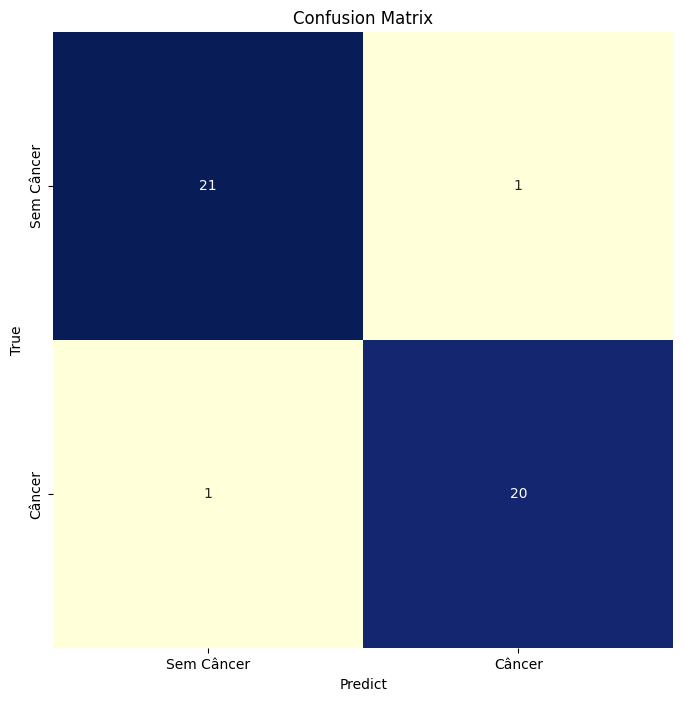

In [ ]:

labels = ['Sem Câncer',
          'Câncer']

plt.subplots(figsize = (8, 8))
sns.heatmap(matriz_confusao, cmap = 'YlGnBu', annot = True, cbar = False, xticklabels = labels, yticklabels = labels)
plt.title('Confusion Matrix')
plt.xlabel('Predict')
plt.ylabel('True')